# Vérification de fake news par la knowledge-base method

In [1]:
# 🔧 ADAPTATION LOCALE : Pas besoin Google Drive sur Linux
import os
import sys
from pathlib import Path

# Définir les chemins de base
PROJECT_ROOT = Path.home() / "Documents/IFT714 Traitement des LN/Projet/Detection_fake_news"
KNOWLEDGE_BRANCH = PROJECT_ROOT / "knowledge_branch"
DATA_DIR = PROJECT_ROOT / "data" / "knowledge_based"

print(f"📂 Répertoire de travail : {KNOWLEDGE_BRANCH}")
print(f"✅ Projet trouvé : {PROJECT_ROOT.exists()}")
print(f"✅ Data trouvée : {DATA_DIR.exists()}")

# Ajouter le knowledge_branch aux imports Python
sys.path.insert(0, str(KNOWLEDGE_BRANCH))

📂 Répertoire de travail : /home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/knowledge_branch
✅ Projet trouvé : True
✅ Data trouvée : True


In [ ]:
# HuggingFace login (optionnel - uniquement si vous avez un compte)
# Décommentez si vous avez besoin de télécharger des modèles privés
try:
    from huggingface_hub import login
    # login()  # À décommenter et configurer si nécessaire
    print("✅ HuggingFace Hub disponible")
except ImportError:
    print("⚠️ huggingface_hub non disponible - utilisation des modèles publics uniquement")

✅ HuggingFace Hub disponible


In [3]:
import os
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f'🎮 Device : {device.upper()} - {device_name}')
print(f'💾 GPU VRAM disponible : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB' if torch.cuda.is_available() else '')

🎮 Device : CUDA - NVIDIA GeForce RTX 4060
💾 GPU VRAM disponible : 8.2 GB


In [4]:
!pip install transformers torch spacy pandas

In [5]:
import requests

url = "https://zenodo.org/record/3609356/files/groundtruth.csv?download=1"
response = requests.get(url, allow_redirects=True)

with open("groundtruth.csv", "wb") as f:
    f.write(response.content)
print("✅ Fichier groundtruth.csv téléchargé avec succès !")

✅ Fichier groundtruth.csv téléchargé avec succès !


In [6]:
import pandas as pd

dataset = pd.read_csv("groundtruth.csv")
print(dataset.head())
print(dataset.columns.to_list)
print(dataset['Verdict'].value_counts())
print(dataset.shape)

# On crée une colonne 'labels' binaire : 1 pour le niveau 1, 0 pour le reste
dataset['labels'] = dataset['Verdict'].apply(lambda x: 1 if x == 1 else 0)

# On ne garde que le texte et le nouveau label
dataset = dataset[['Text', 'labels']]

   Sentence_id                                               Text  \
0           26      You know, I saw a movie - "Crocodile Dundee."   
1           80  We're consuming 50 percent of the world's coca...   
2          129   That answer was about as clear as Boston harbor.   
3          131                          Let me help the governor.   
4          172  We've run up more debt in the last eight years...   

           Speaker   Speaker_title Speaker_party         File_id  Length  \
0      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       9   
1  Michael Dukakis        Governor      DEMOCRAT  1988-09-25.txt       8   
2      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       9   
3      George Bush  Vice President    REPUBLICAN  1988-09-25.txt       5   
4  Michael Dukakis        Governor      DEMOCRAT  1988-09-25.txt      22   

   Line_number  Sentiment  Verdict  
0           26   0.000000        0  
1           80  -0.740979        1  
2          129   

In [7]:
dataset.head()

,Text,labels
0,"You know, I saw a movie - ""Crocodile Dundee.""",0
1,We're consuming 50 percent of the world's coca...,1
2,That answer was about as clear as Boston harbor.,0
3,Let me help the governor.,0
4,We've run up more debt in the last eight years...,1


In [8]:
from datasets import Dataset, DatasetDict

# On transforme le DataFrame en Dataset Hugging Face
hg_dataset = Dataset.from_pandas(dataset[['Text', 'labels']])

# on divise notre dataset en train/test

split_dataset = hg_dataset.train_test_split(test_size=0.2)

# Partie Claim detecion

In [9]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch

model_checkpoint = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

def tokenize_function(examples):
    # L'option batched=True envoie une liste de textes ici
    return tokenizer(examples["Text"], padding="max_length", truncation=True)

tokenized_datasets = split_dataset.map(tokenize_function, batched=True)

model = AutoModelForSequenceClassification.from_pretrained(model_checkpoint, num_labels=2)

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
)

# Lancer l'entraînement
trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/825 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=156, training_loss=0.17810563552073944, metrics={'train_runtime': 71.2056, 'train_samples_per_second': 34.759, 'train_steps_per_second': 2.191, 'total_flos': 327856811673600.0, 'train_loss': 0.17810563552073944, 'epoch': 3.0})

In [10]:
trainer.save_model("./claim_detector_model")
tokenizer.save_pretrained("./claim_detector_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./claim_detector_model/tokenizer_config.json',
 './claim_detector_model/tokenizer.json')

In [11]:
from transformers import pipeline

claim_pipeline = pipeline("text-classification", model="./claim_detector_model", tokenizer="./claim_detector_model", device=0)


def detect_claim(text, threshold=0.2):
    results = claim_pipeline(text)
    # Dans ton modèle, vérifie si LABEL_1 est bien le "Check-worthy"
    # Si le score pour LABEL_1 est > 0.2, on y va.
    score_claim = next((r['score'] for r in results if r['label'] == 'LABEL_1'), 0)
    return score_claim > threshold, score_claim

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Prédiction sur l'ensemble de test
predictions = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

# matrice de confusion

confusion_matrix = confusion_matrix(labels, preds)
print("Matrice de confusion :")
print(confusion_matrix)

# rapport de classification
print("\nRapport de classification :")

print(classification_report(labels, preds, target_names=["Non-Claim", "Claim"]))

Matrice de confusion :
[[148   5]
 [  4  50]]

Rapport de classification :
              precision    recall  f1-score   support

   Non-Claim       0.97      0.97      0.97       153
       Claim       0.91      0.93      0.92        54

    accuracy                           0.96       207
   macro avg       0.94      0.95      0.94       207
weighted avg       0.96      0.96      0.96       207



les métriques sont satisfaisantes pour la classe claim, elles sont toutes supérieures à 95%. On va maintenant faire un autre test pour savoir si le claim detector est vraiment efficace

In [13]:
print(detect_claim("The unemployment rate in France is 7.5%", threshold=0.5))
print(detect_claim("The Eiffel Tower is 330 meters tall", threshold=0.5))
print(detect_claim("there are 6 continents on planet earth", threshold=0.5))
print(detect_claim("Avatar is a great movie", threshold=0.5))
print(detect_claim("I think this movie is great", threshold=0.5))
print(detect_claim("Hello, how are you today?", threshold=0.5))

(True, 0.9361488819122314)
(True, 0.7076147794723511)
(True, 0.6076305508613586)
(False, 0)
(False, 0)
(False, 0)


In [14]:
! pip install wikipedia-api

In [15]:
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm
!python -m spacy download es_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 7.6 MB/s  0:00:01 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 7.5 MB/s  0:00:02 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 7.9 MB/s  0:00:01 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')


In [16]:
! ls

claim_detection.py     evidence_retrieval.py	    knowledge.ipynb
claim_detector_model   groundtruth.csv		    results
claim_verification.py  knowledge_based_tests.ipynb


In [17]:
#%cd /content/drive/MyDrive/Projet_NLP/knowledge_branch

In [24]:
! ls

claim_detection.py     groundtruth.csv		    results
claim_detector_model   knowledge_based_tests.ipynb  train.jsonl
claim_verification.py  knowledge.ipynb
evidence_retrieval.py  __pycache__


In [27]:
# ✅ ADAPTATION : Imports depuis le répertoire local (sys.path déjà configuré)
try:
    from evidence_retrieval import EvidenceRetriever
    print("✅ EvidenceRetriever importé avec succès")
except ImportError as e:
    print(f"❌ Erreur d'import : {e}")
    print(f"   Vérifiez que evidence_retrieval.py existe dans : {KNOWLEDGE_BRANCH}")

# Remplace par tes vraies clés obtenues sur les portails
WOLFRAM_APPID = "LEU7Y6728T"
GOOGLE_API_KEY = None
GOOGLE_CSE_ID = "151bf4aa4eae44373"

# Initialisation du nouveau Retriever
retriever = EvidenceRetriever(
    google_api_key=GOOGLE_API_KEY,
    google_cse_id=GOOGLE_CSE_ID,
    wolfram_app_id=WOLFRAM_APPID,
    config_languages={'en': 'en_core_web_sm', 'fr': 'fr_core_news_sm', 'es': 'es_core_news_sm'}
)

test_claims = {
    "The Eiffel Tower is 330 meters tall": "en",
    "Le taux de chômage en France est de 7%": "fr",
    "La capital de España es Madrid": "es"
}

print("--- Lancement du Test Multi-Sources ---\n")

for claim, language in test_claims.items():
    # On utilise la méthode qui gère les priorités
    evidence = retriever.get_evidence(claim, language)

    if evidence:
        source_name = evidence.get('title', 'Inconnue')
        print(f"✅ Trouvé via [{source_name}] ({language})")
        print(f"Phrase : {claim}")
        print(f"Preuve : {evidence['content'][:150]}...")
        print(f"Lien : {evidence.get('url', 'N/A')}\n")
    else:
        print(f"❌ Aucune preuve trouvée pour : {claim}\n")

✅ EvidenceRetriever importé avec succès
--- Lancement du Test Multi-Sources ---

✅ Trouvé via [Eiffel Tower] (en)
Phrase : The Eiffel Tower is 330 meters tall
Preuve : The Eiffel Tower (  EYE-fəl; French: Tour Eiffel [tuʁ ɛfɛl] ) is a lattice tower on the Champ de Mars in Paris, France. It is named after the engineer...
Lien : https://en.wikipedia.org/wiki/Eiffel_Tower

✅ Trouvé via [France] (fr)
Phrase : Le taux de chômage en France est de 7%
Preuve : La France, en forme longue la République française, est un État souverain transcontinental dont le territoire métropolitain s'étend en Europe de l'Oue...
Lien : https://fr.wikipedia.org/wiki/France

✅ Trouvé via [El Español (Madrid)] (es)
Phrase : La capital de España es Madrid
Preuve : El Español fue un periódico editado en Madrid entre 1835 y 1837 y, en una segunda época, de 1845 a 1848. Fue fundado por Andrés Borrego....
Lien : https://es.wikipedia.org/wiki/El_Espa%C3%B1ol_(Madrid)



# Partie Claim Verification

In [28]:
# ✅ ADAPTATION : Import ClaimVerifier depuis le répertoire local
try:
    from claim_verification import ClaimVerifier
    print("✅ ClaimVerifier importé avec succès")
except ImportError as e:
    print(f"❌ Erreur d'import : {e}")
    print(f"   Vérifiez que claim_verification.py existe dans : {KNOWLEDGE_BRANCH}")

# On initialise le verifier
claimverifier = ClaimVerifier()
result = claimverifier.verify("New York is in the United States", "New York is one of the biggest city of the United States")
print(f"✅ Vérification test effectuée : {result}")

✅ ClaimVerifier importé avec succès


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Vérification test effectuée : ('SUPPORTED', 0.9923887848854065)


In [29]:
# --- CONFIGURATION ---

verifier = ClaimVerifier()
text_to_check = "Tom Cruise was born in 1962"
FORCE_CHECK = True # Pour forcer la vérification même si BERT hésite

is_claim, detection_score = detect_claim(text_to_check, threshold=0.2)

if is_claim or FORCE_CHECK:
    if not is_claim:
        print(f"⚠️ Détection faible ({detection_score:.2f}), mais on vérifie quand même...")
    else:
        print(f"🔍 Claim détecté ! (Confiance: {detection_score:.2f})")

    # ÉTAPE 2 : Récupération
    evidence = retriever.get_evidence(text_to_check, language='en')

    if evidence:
        # ÉTAPE 3 : Vérification
        verdict, confidence = verifier.verify(text_to_check, evidence['content'])
        print(f"\n--- RÉSULTAT FINAL ---")
        print(f"Phrase : {text_to_check}")
        print(f"Verdict : {verdict} (Score NLI: {confidence:.2f})")
        print(f"Source : {evidence['url']} (via {evidence.get('title')})")
    else:
        print("❌ Aucune preuve trouvée.")
else:
    print("ℹ️ Cette phrase n'a pas été jugée digne d'intérêt par le détecteur.")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


⚠️ Détection faible (0.00), mais on vérifie quand même...

--- RÉSULTAT FINAL ---
Phrase : Tom Cruise was born in 1962
Verdict : SUPPORTED (Score NLI: 1.00)
Source : https://en.wikipedia.org/wiki/Tom_Cruise (via Tom Cruise)


Evaluation des métriques de performances pour EvidenceRetriever et ClaimVerifier

In [32]:
import pandas as pd
import os

# 📂 Adapter le chemin pour l'environnement local
fever_file = str(DATA_DIR / 'train.jsonl')
print(f"📂 Chargement depuis : {fever_file}")
print(f"✅ Fichier existe : {os.path.exists(fever_file)}")

if os.path.exists(fever_file):
    df_fever = pd.read_json(fever_file, lines=True)
    
    mapping = {
        'SUPPORTS': 'SUPPORTED',
        'REFUTES': 'REFUTED',
        'NOT ENOUGH INFO': 'NEUTRAL / NOT ENOUGH INFO'
    }
    df_fever['label'] = df_fever['label'].replace(mapping)

    # 2. Équilibrage (on prend 30 exemplaires de chaque classe présente dans le mapping)
    n_per_class = 30
    balanced_dfs = []
    for label_value in df_fever['label'].unique():
        subset = df_fever[df_fever['label'] == label_value].sample(n=min(n_per_class, len(df_fever[df_fever['label'] == label_value])), random_state=42)
        balanced_dfs.append(subset)
    
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)

    # 3. Mélanger le dataset (pour ne pas avoir tous les SUPPORTED au début)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

    # 4. Sélection des colonnes et conversion
    test_data = balanced_df[['claim', 'label']]
    test_data_list = test_data.to_dict('records')

    print(f"✅ Dataset équilibré créé : {len(test_data_list)} instances.")
    print(balanced_df['label'].value_counts())
else:
    print("❌ Fichier train.jsonl non trouvé. Assurez-vous d'avoir téléchargé les données FEVER.")

📂 Chargement depuis : /home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/data/knowledge_based/train.jsonl
✅ Fichier existe : True
✅ Dataset équilibré créé : 90 instances.
label
REFUTED                      30
SUPPORTED                    30
NEUTRAL / NOT ENOUGH INFO    30
Name: count, dtype: int64


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

def check_recovery_by_class(retriever, test_set):
    stats = {}
    for item in test_set:
        label = item['label']
        if label not in stats:
            stats[label] = {'total': 0, 'retrieved': 0} # On garde 'retrieved'
        stats[label]['total'] += 1
        evidence = retriever.get_evidence(item['claim'])

        if evidence and evidence['content'] and len(evidence['content']) > 20:
            stats[label]['retrieved'] += 1 # Correction ici

    print("\n🔍 ANALYSE DE RÉCUPÉRATION PAR CLASSE :")
    for label, count in stats.items():
        # Utiliser 'retrieved' au lieu de 'found'
        rate = (count['retrieved'] / count['total']) * 100
        print(f"Label {label:25} : {rate:.2f}% ({count['retrieved']}/{count['total']})")



def chek_verification(verifier, retriever, test_set):
    y_true = []
    y_pred = []
    retrieval_success = 0 # Initialisation manquante

    print(f"🚀 Début de l'évaluation sur {len(test_set)} instances...")

    for item in test_set:
        claim = item['claim']
        true_label = item['label']

        evidence = retriever.get_evidence(claim, language='en')

        if evidence and evidence['content']:
            retrieval_success += 1
            evidence_text = evidence['content']
        else:
            evidence_text = ""

        pred_label, score = verifier.verify(claim, evidence_text)
        y_true.append(true_label)
        y_pred.append(pred_label)
    # Calcul des métriques

    print("\n" + "="*30)
    print("RÉSULTATS DE L'ÉVALUATION")
    print("="*30)

    # Rapport de classification (Precision, Recall, F1)
    print("\n📋 Rapport de Classification :")
    print(classification_report(y_true, y_pred))

    # Matrice de confusion
    cm = confusion_matrix(y_true, y_pred, labels=["SUPPORTED", "REFUTED", "NEUTRAL / NOT ENOUGH INFO"])
    plot_confusion_matrix(cm)


def plot_confusion_matrix(cm):
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["SUPP", "REFUT", "NEUT"],yticklabels=["SUPP", "REFUT", "NEUT"])
  plt.ylabel('Vrai Label')
  plt.xlabel('Prédiction')
  plt.title('Matrice de Confusion - Flux Sémantique')
  plt.show()



Exécution du pipeline final

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



🔍 ANALYSE DE RÉCUPÉRATION PAR CLASSE :
Label REFUTED                   : 53.33% (16/30)
Label SUPPORTED                 : 63.33% (19/30)
Label NEUTRAL / NOT ENOUGH INFO : 70.00% (21/30)
🚀 Début de l'évaluation sur 90 instances...


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



RÉSULTATS DE L'ÉVALUATION

📋 Rapport de Classification :
                           precision    recall  f1-score   support

NEUTRAL / NOT ENOUGH INFO       0.45      0.47      0.46        30
          NOT ENOUGH INFO       0.00      0.00      0.00         0
                  REFUTED       0.60      0.30      0.40        30
                SUPPORTED       0.50      0.17      0.25        30

                 accuracy                           0.31        90
                macro avg       0.39      0.23      0.28        90
             weighted avg       0.52      0.31      0.37        90



/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/juul/Documents/IFT714 Traitement des LN/Projet/Detection_fake_news/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true

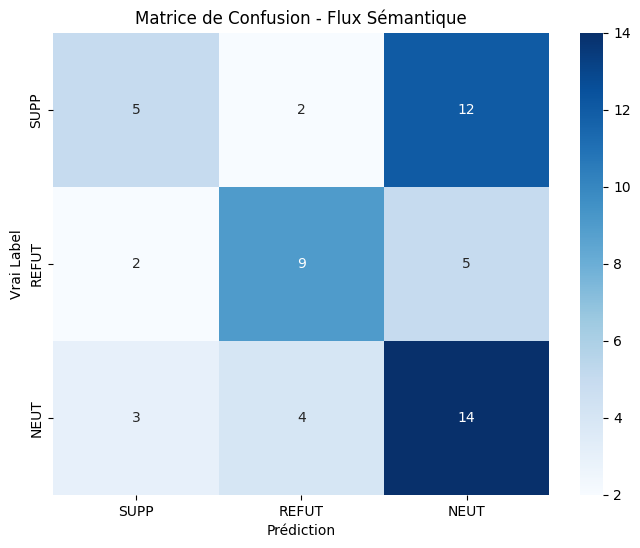

In [34]:
evidence_retriever = EvidenceRetriever(google_api_key=None, google_cse_id="151bf4aa4eae44373", wolfram_app_id="LEU7Y6728T")
claim_verifier = ClaimVerifier()
check_recovery_by_class(evidence_retriever, test_data_list)
chek_verification(claim_verifier,evidence_retriever, test_data_list)

In [35]:
# ✅ ADAPTATION : Utiliser les variables de chemin définies au début
retriever = EvidenceRetriever(
    google_api_key=GOOGLE_API_KEY,
    google_cse_id="151bf4aa4eae44373",
    wolfram_app_id="LEU7Y6728T",
    config_languages={'en': 'en_core_web_sm', 'fr': 'fr_core_news_sm', 'es': 'es_core_news_sm'}
)

verifier = ClaimVerifier()

def process_full_text(text, language='en'):
    nlp = retriever.nlp_models.get(language)
    doc = nlp(text)
    final_report = []

    print(f"\n🚀 --- DÉBUT DU TRAITEMENT ({language.upper()}) ---")

    for sent in doc.sents:
        sentence = sent.text.strip()
        if not sentence: continue

        # 1. ÉTAPE DÉTECTION
        is_claim, detection_score = detect_claim(sentence, threshold=0.5)
        entites_trouvees = [ent.text for ent in sent.ents if ent.label_ in ['GPE', 'PERSON', 'DATE', 'ORG']]
        has_entities = len(entites_trouvees) > 0

        print(f"\n--- 📝 PHRASE : '{sentence}'")
        print(f"   [DÉTECTION] Score IA: {detection_score:.2f} | Entités: {entites_trouvees}")

        if is_claim or has_entities:
            # 2. ÉTAPE RÉCUPÉRATION
            print(f"   [RETRIEVER] Recherche de preuves en cours...")
            evidence = retriever.get_evidence(sentence, language)

            if evidence:
                source_name = evidence.get('title', 'Inconnue')
                # On print un extrait de ce que le retriever a VRAIMENT trouvé
                print(f"   ✅ SOURCE TROUVÉE : {source_name}")
                print(f"   📄 CONTENU EXTRAIT : {evidence['content'][:150]}...")
                print(f"   🔗 URL : {evidence.get('url')}")

                # 3. ÉTAPE VÉRIFICATION (Le Verifier a déjà ses propres prints)
                verdict, score_verif = verifier.verify(sentence, evidence['content'])

                final_report.append({
                    "phrase": sentence,
                    "verdict": verdict,
                    "score_detection": detection_score,
                    "score_verification": score_verif,
                    "source": evidence['url'],
                    "source_name": source_name
                })
            else:
                print(f"   ❌ RETRIEVER : Aucune preuve trouvée.")
                final_report.append({"phrase": sentence, "verdict": "NO EVIDENCE FOUND"})
        else:
            print(f"   ⏭️ IGNORÉ : Ne semble pas être un fait à vérifier.")

    print(f"\n--- ✅ TRAITEMENT TERMINÉ ---")
    return final_report

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: MoritzLaurer/DeBERTa-v3-base-mnli-fever-anli
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [36]:
mon_article = """
Algeria is located in Africa. The Eiffel Tower is in Paris. The Eiffel Tower was built in 1990.

"""

resultats = process_full_text(mon_article, language='en')

# Affichage propre
for r in resultats:
    print(f"[{r['verdict']}] {r['phrase']} (Source: {r.get('source', 'N/A')})")


🚀 --- DÉBUT DU TRAITEMENT (EN) ---

--- 📝 PHRASE : 'Algeria is located in Africa.'
   [DÉTECTION] Score IA: 0.00 | Entités: ['Algeria']
   [RETRIEVER] Recherche de preuves en cours...
   ✅ SOURCE TROUVÉE : Algeria at the Africa Cup of Nations
   📄 CONTENU EXTRAIT : Algeria have appeared in the finals of the Africa Cup of Nations on twenty occasions. The side's first participation was in 1968 in Ethiopia. Algeria ...
   🔗 URL : https://en.wikipedia.org/wiki/Algeria_at_the_Africa_Cup_of_Nations

--- 📝 PHRASE : 'The Eiffel Tower is in Paris.'
   [DÉTECTION] Score IA: 0.00 | Entités: ['Paris']
   [RETRIEVER] Recherche de preuves en cours...
   ✅ SOURCE TROUVÉE : WolframAlpha
   📄 CONTENU EXTRAIT : The Eiffel Tower is a lattice tower on the Champ de Mars in Paris, France. It is named after the engineer Gustave Eiffel, whose company designed and b...
   🔗 URL : https://www.wolframalpha.com

--- 📝 PHRASE : 'The Eiffel Tower was built in 1990.'
   [DÉTECTION] Score IA: 0.71 | Entités: ['1990'